# Crop Classification Using Multitemporal Sentinel-2 imagery

Traditional crop identification via manual farm visits is expensive, time-consuming, and prone to data collection errors. Remote sensing combined with machine learning offers a scalable and cost-effective alternative.

The task is to develop a pixel-level classification model that can distinguish between **cocoa**, **rubber**, and **oil palm** plantations using open-source Sentinel-2 data.

**References:** [Competition](https://zindi.world/competitions/cote-divoire-byte-sized-agriculture-challenge) · [Data](https://zindi.world/competitions/cote-divoire-byte-sized-agriculture-challenge/data)

## 1. Environment and configuration

Input files are read from `MyDrive/crop_classify`; outputs are written to `crop_classify/results`.
| Input | Description |
|---|---|
| `TrainDataset.csv` | Monthly observations and crop labels |
| `TestDataset.csv` | Unlabelled monthly observations |
| `SampleSubmission.csv` | Required sample IDs and output schema |
| `S2Images/train` | Training GeoTIFFs |
| `S2Images/test` | Test GeoTIFFs |

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


### 1.1 Package imports

In [62]:
%pip install -q rasterio

from pathlib import Path
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

### 1.2 Project paths

`DATA_PATH` defines the input directory. Image directories are verified and the results directory is created if absent.

In [3]:
DATA_PATH = Path('/content/drive/MyDrive/crop_classify')
TRAIN_IMAGES_PATH = DATA_PATH / 'S2Images' / 'train'
TEST_IMAGES_PATH = DATA_PATH / 'S2Images' / 'test'
RESULTS_PATH = DATA_PATH / 'results'
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

assert TRAIN_IMAGES_PATH.exists(), 'Check the location of the training images.'
assert TEST_IMAGES_PATH.exists(), 'Check the location of the test images.'

## 2. Dataset inspection

The training, test and submission tables are loaded for schema inspection and record checks.

In [4]:
train = pd.read_csv(DATA_PATH / 'TrainDataset.csv')
test = pd.read_csv(DATA_PATH / 'TestDataset.csv')
sample_submission = pd.read_csv(DATA_PATH / 'SampleSubmission.csv')

train.head()

,ID,year,month,tifPath,Target,class
0,ID_h14T0B_Jan,2024,Jan,/content/drive/MyDrive/train_s2_images_new_fin...,Rubber,3
1,ID_KbyKOr_Jan,2024,Jan,/content/drive/MyDrive/train_s2_images_new_fin...,Rubber,3
2,ID_t4Tmmn_Jan,2024,Jan,/content/drive/MyDrive/train_s2_images_new_fin...,Rubber,3
3,ID_yipWoC_Jan,2024,Jan,/content/drive/MyDrive/train_s2_images_new_fin...,Rubber,3
4,ID_XKiksa_Jan,2024,Jan,/content/drive/MyDrive/train_s2_images_new_fin...,Rubber,3


In [5]:
test.head()

,ID,year,month,tifPath
0,ID_731818_Jan,2024,Jan,/content/drive/MyDrive/test_s2_images_new_fina...
1,ID_790093_Jan,2024,Jan,/content/drive/MyDrive/test_s2_images_new_fina...
2,ID_931033_Jan,2024,Jan,/content/drive/MyDrive/test_s2_images_new_fina...
3,ID_079024_Jan,2024,Jan,/content/drive/MyDrive/test_s2_images_new_fina...
4,ID_691532_Jan,2024,Jan,/content/drive/MyDrive/test_s2_images_new_fina...


In [6]:
sample_submission.head()

,ID,Target
0,ID_731818,NaN
1,ID_790093,NaN
2,ID_931033,NaN
3,ID_079024,NaN
4,ID_691532,NaN


### 2.1 Data schema

| Field | Role |
|---|---|
| `ID` | Sample identifier with a month suffix |
| `year`, `month` | Observation period |
| `tifPath` | Source image path |
| `Target` | Crop label: Cocoa, Palm or Rubber |
| `class` | Numeric label; excluded from predictors |

The supplied tables contain **11,436 training observations** and **3,384 test observations**. Submission targets are template values, not training labels.

In [7]:
print('Training rows:', len(train))
print('Test rows:', len(test))
print('Submission rows:', len(sample_submission))

print()
print('Missing values in training data:')
print(train.isna().sum())

Training rows: 11436
Test rows: 3384
Submission rows: 282

Missing values in training data:
ID            0
year          0
month         0
tifPath    4003
Target        0
class         0
dtype: int64


### 2.2 Sample identifiers

The final month suffix is removed from each observation ID to recover its sample ID. Month abbreviations are mapped to calendar numbers for temporal aggregation.

In [10]:
month_numbers = {calendar.month_abbr[i]: i for i in range(1, 13)}

for data in [train, test]:
    data['sample_id'] = data['ID'].str.rsplit('_', n=1).str[0]
    data['month_number'] = data['month'].map(month_numbers)

train[['ID', 'sample_id', 'month', 'month_number']].head()

,ID,sample_id,month,month_number
0,ID_h14T0B_Jan,ID_h14T0B,Jan,1
1,ID_KbyKOr_Jan,ID_KbyKOr,Jan,1
2,ID_t4Tmmn_Jan,ID_t4Tmmn,Jan,1
3,ID_yipWoC_Jan,ID_yipWoC,Jan,1
4,ID_XKiksa_Jan,ID_XKiksa,Jan,1


### 2.3 Integrity checks

Checks enforce unique observations, valid 2024 month records, consistent sample labels, disjoint training and test samples, and agreement between test and submission IDs.

In [9]:
crop_names = ['Cocoa', 'Palm', 'Rubber']

for data in [train, test]:
    assert data['ID'].is_unique, 'Repeated monthly IDs found.'
    assert data['month_number'].notna().all(), 'An unfamiliar month name was found.'
    assert data['year'].eq(2024).all(), 'This notebook expects the supplied 2024 data.'
    assert data['ID'].str.rsplit('_', n=1).str[1].eq(data['month']).all()
    assert not data.duplicated(['sample_id', 'month_number']).any()

assert train['Target'].isin(crop_names).all()
assert train.groupby('sample_id')['Target'].nunique().eq(1).all()
assert set(train['sample_id']).isdisjoint(test['sample_id'])
assert sample_submission['ID'].is_unique
assert set(sample_submission['ID']) == set(test['sample_id'])

### 2.4 Class distribution

Labels are counted once per sample. The dataset contains **953 labelled samples**—235 Cocoa, 313 Palm and 405 Rubber—and **282 test samples**.

Training samples: 953
Test samples: 282
Target
Rubber    405
Palm      313
Cocoa     235
Name: count, dtype: int64


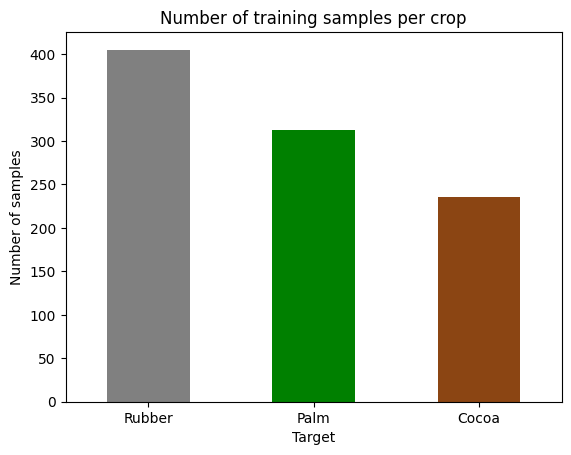

In [13]:
labels = train.groupby('sample_id')['Target'].first()

print('Training samples:', len(labels))
print('Test samples:', test['sample_id'].nunique())
print(labels.value_counts())

labels.value_counts().plot.bar(color=['gray', 'green', 'saddlebrown'])
plt.title('Number of training samples per crop')
plt.ylabel('Number of samples')
plt.xticks(rotation=0)
plt.show()

## 3. Image availability

Source filenames are resolved against the configured image directories. Missing `tifPath` values represent unavailable monthly observations.

In [14]:
def update_image_path(old_path, image_folder):
    # A missing path stays missing.
    if pd.isna(old_path):
        return None

    filename = Path(old_path).name
    return image_folder / filename

train['image_path'] = train['tifPath'].apply(
    lambda path: update_image_path(path, TRAIN_IMAGES_PATH))
test['image_path'] = test['tifPath'].apply(
    lambda path: update_image_path(path, TEST_IMAGES_PATH))

train[['tifPath', 'image_path']].head()

,tifPath,image_path
0,/content/drive/MyDrive/train_s2_images_new_fin...,/content/drive/MyDrive/crop_classify/S2Images/...
1,/content/drive/MyDrive/train_s2_images_new_fin...,/content/drive/MyDrive/crop_classify/S2Images/...
2,/content/drive/MyDrive/train_s2_images_new_fin...,/content/drive/MyDrive/crop_classify/S2Images/...
3,/content/drive/MyDrive/train_s2_images_new_fin...,/content/drive/MyDrive/crop_classify/S2Images/...
4,/content/drive/MyDrive/train_s2_images_new_fin...,/content/drive/MyDrive/crop_classify/S2Images/...


### 3.1 File verification

Unavailable months and unresolved file references are reported separately. Unresolved references stop execution.

In [16]:
for name, data in [('Train', train), ('Test', test)]:
    paths = data['image_path'].dropna()
    missing_files = [str(path) for path in paths if not path.is_file()]
    print(name, '- months without images:', data['image_path'].isna().sum())
    print(name, '- referenced files not found:', len(missing_files))
    assert len(missing_files) == 0, f'Check these file locations: {missing_files[:3]}'

Train - months without images: 4003
Train - referenced files not found: 0
Test - months without images: 1183
Test - referenced files not found: 0


## 4. Image preprocessing

Here's a complete list of **Sentinel-2 bands** along with their **descriptions**, **wavelengths**, and **spatial resolutions**:

---

### 🛰️ **Sentinel-2 Band Overview**

| Band | Name                    | Wavelength (nm) | Resolution (m) | Description |
|------|-------------------------|-----------------|----------------|-------------|
| B1   | Coastal aerosol         | 443             | 60             | Useful for atmospheric correction and aerosol detection. |
| B2   | Blue                    | 490             | 10             | Penetrates water; used for vegetation, water bodies, and coastal mapping. |
| B3   | Green                   | 560             | 10             | Good for assessing plant health and measuring biomass. |
| B4   | Red                     | 665             | 10             | Key band for vegetation discrimination and chlorophyll absorption. |
| B5   | Red Edge 1              | 705             | 20             | Useful for detecting subtle changes in vegetation. |
| B6   | Red Edge 2              | 740             | 20             | Further detail on vegetation, especially stress and growth stages. |
| B7   | Red Edge 3              | 783             | 20             | Extended vegetation monitoring. |
| B8   | NIR (Near Infrared)     | 842             | 10             | Excellent for vegetation vigor, biomass, and land-water contrast. |
| B8A  | Narrow NIR (Red Edge 4) | 865             | 20             | Sensitive to chlorophyll content and canopy structure. |
| B9   | Water Vapor             | 945             | 60             | Atmospheric correction (water vapor absorption). |
| B10  | SWIR – Cirrus           | 1375            | 60             | Detects high-altitude clouds (cirrus); not used for land analysis. |
| B11  | SWIR 1                  | 1610            | 20             | Differentiates clouds, snow, and vegetation moisture. |
| B12  | SWIR 2                  | 2190            | 20             | Useful for geology, soil, and burnt area mapping. |

---

### ✅ Band Groupings by Application

#### **RGB (Natural Color)**
- **B4 (Red)**
- **B3 (Green)**
- **B2 (Blue)**

#### **Vegetation Indices**
- **NDVI:** B8 (NIR) & B4 (Red)
- **EVI:** B8 (NIR), B4 (Red), B2 (Blue)
- **SAVI:** B8 (NIR) & B4 (Red)
- **NDRE:** B8A (Narrow NIR) & B5 (Red Edge)

#### **Cloud/Atmosphere Analysis**
- B1, B9, B10

#### **Snow/Ice Monitoring**
- B3, B11, B12

---


In [37]:
band = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6',
              'B7', 'B8', 'B8A', 'B9', 'B11', 'B12']

example_path = train['image_path'].dropna().iloc[50]

with rasterio.open(example_path) as image:
    print('Bands:', image.count)
    print('Rows and columns:', image.height, image.width)
    print('Band names:', image.descriptions)

Bands: 12
Rows and columns: 51 51
Band names: ('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12')


### 4.1 Band ordering, masking and scaling

Bands are reordered from their metadata where available; unnamed bands use the declared 12-band sequence. Unexpected layouts are rejected.

No-data masks and pixels with zero values across all bands are excluded. Values are converted to floating point and scaled using GeoTIFF scale/offset metadata, or divided by 10,000 when that metadata is at its default.

In [24]:
def read_image(image_path):
    with rasterio.open(image_path) as image:
        assert image.count == 12, 'Expected a 12-band image.'
        names = list(image.descriptions)

        if all(name in [None, ''] for name in names):
            order = list(range(1, 13))
        else:
            assert set(names) == set(band), 'Unexpected band names.'
            order = [names.index(name) + 1 for name in band]

        bands = image.read(order, masked=True).astype('float32').filled(np.nan)
        bands[:, np.all(bands == 0, axis=0)] = np.nan
        scales = np.array(image.scales)[np.array(order) - 1]
        offsets = np.array(image.offsets)[np.array(order) - 1]

    if np.all(scales == 1) and np.all(offsets == 0):
        bands = bands / 10000.0
    else:
        bands = bands * scales[:, None, None] + offsets[:, None, None]

    bands[~np.isfinite(bands)] = np.nan
    return bands

### 4.2 Natural-colour composite

The red, green and blue bands form the preview. A 2nd–98th percentile stretch affects display only; feature extraction uses the scaled band values.

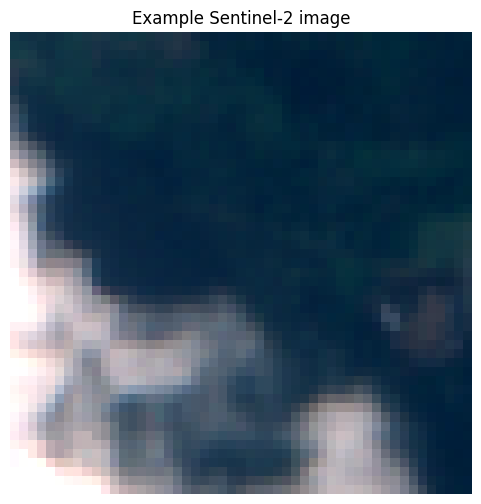

In [38]:
bands = read_image(example_path)
rgb = np.stack([bands[3], bands[2], bands[1]], axis=-1)

# Stretch the visible range so the image is easier to see.
low, high = np.nanpercentile(rgb, [2, 98])
rgb_display = np.clip((rgb - low) / max(high - low, 0.000001), 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(np.nan_to_num(rgb_display))
plt.title('Example Sentinel-2 image')
plt.axis('off')
plt.show()

## 5. Spectral Indices

Four indices describe vegetation and surface conditions.

| Index | Spectral property |
|---|---|
| NDVI | Vegetation greenness |
| NDMI | Vegetation moisture sensitivity |
| EVI | Vegetation signal with background and atmospheric adjustments |
| SAVI | Vegetation signal with soil-background adjustment |

Invalid divisions and near-zero denominators return missing values.

In [39]:
def safe_divide(numerator, denominator):
    result = np.full_like(numerator, np.nan, dtype='float32')
    valid = np.isfinite(numerator) & np.isfinite(denominator)
    valid = valid & (np.abs(denominator) > 0.000001)
    np.divide(numerator, denominator, out=result, where=valid)
    return result

### 5.1 Band selection and index calculation

Selected bands are blue, green, red, near-infrared and two shortwave-infrared bands. EVI and SAVI are calculated after reflectance scaling.

In [40]:
def get_bands_and_indices(bands):
    blue = bands[1]
    green = bands[2]
    red = bands[3]
    nir = bands[7]
    swir1 = bands[10]
    swir2 = bands[11]

    ndvi = safe_divide(nir - red, nir + red)
    ndmi = safe_divide(nir - swir1, nir + swir1)
    evi = 2.5 * safe_divide(nir - red, nir + 6 * red - 7.5 * blue + 1)
    savi = 1.5 * safe_divide(nir - red, nir + red + 0.5)

    return {'Blue': blue, 'Green': green, 'Red': red, 'NIR': nir,
            'SWIR1': swir1, 'SWIR2': swir2,
            'NDVI': ndvi, 'NDMI': ndmi, 'EVI': evi, 'SAVI': savi}

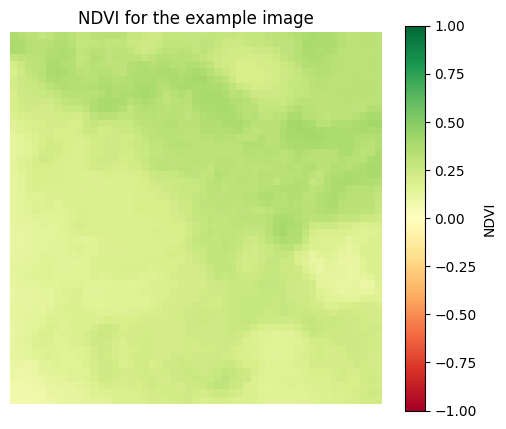

In [43]:
channels = get_bands_and_indices(bands)

plt.figure(figsize=(6, 5))
plt.imshow(channels['NDVI'], cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI')
plt.title('NDVI for the example image')
plt.axis('off')
plt.show()

## 6. Image-level feature extraction

Mean, median and standard deviation are calculated over valid pixels for each of the ten spectral variables, producing **30 features per image**.


In [44]:
def extract_features(image_path):
    bands = read_image(image_path)
    channels = get_bands_and_indices(bands)
    features = {}

    for name, values in channels.items():
        # Keep valid pixels only.
        pixels = values[np.isfinite(values)]
        if len(pixels) == 0:
            features[name + '_mean'] = np.nan
            features[name + '_median'] = np.nan
            features[name + '_std'] = np.nan
        else:
            features[name + '_mean'] = pixels.mean()
            features[name + '_median'] = np.median(pixels)
            features[name + '_std'] = pixels.std()

    return features

### 6.1 Feature inspection

A single-image extraction verifies the feature count and provides a preview of the resulting values.

In [45]:
example_features = extract_features(example_path)

print('Number of features:', len(example_features))
pd.Series(example_features).head(12)

Number of features: 30


,0
Blue_mean,0.260546
Blue_median,0.239600
Blue_std,0.039946
Green_mean,0.246828
Green_median,0.224400
Green_std,0.044752
Red_mean,0.230599
Red_median,0.200500
Red_std,0.057537
NIR_mean,0.377465


### 6.2 Monthly feature tables

Features are extracted for each available image and stored with its sample ID and month. Observations without imagery are skipped; sample-level coverage is checked after aggregation.

In [46]:
def make_monthly_features(data):
    rows = []

    for _, row in tqdm(data.iterrows(), total=len(data)):
        if pd.isna(row['image_path']):
            continue

        features = extract_features(row['image_path'])
        features['sample_id'] = row['sample_id']
        features['month_number'] = row['month_number']
        rows.append(features)

    return pd.DataFrame(rows)

In [ ]:
train_monthly = make_monthly_features(train)
train_monthly.to_csv(RESULTS_PATH / 'train_monthly_features.csv', index=False)
train_monthly.head()

  0%|          | 0/11436 [00:00<?, ?it/s]

,Blue_mean,Blue_median,Blue_std,Green_mean,Green_median,Green_std,Red_mean,Red_median,Red_std,NIR_mean,...,NDMI_median,NDMI_std,EVI_mean,EVI_median,EVI_std,SAVI_mean,SAVI_median,SAVI_std,sample_id,month_number
0,0.226786,0.2268,0.001518,0.209776,0.2097,0.002233,0.183577,0.1832,0.002366,0.351271,...,0.139614,0.024578,0.556433,0.560142,0.058759,0.242547,0.243761,0.025996,ID_h14T0B,1
1,0.224909,0.2247,0.002185,0.210361,0.2099,0.003932,0.185659,0.1847,0.004356,0.352760,...,0.097877,0.023883,0.535304,0.535831,0.047152,0.241085,0.240852,0.020523,ID_KbyKOr,1
2,0.224994,0.2247,0.002418,0.211934,0.2116,0.004442,0.188547,0.1876,0.006223,0.355098,...,0.086382,0.039138,0.519465,0.518286,0.093365,0.238267,0.237980,0.041182,ID_t4Tmmn,1
3,0.227710,0.2273,0.003287,0.214534,0.2144,0.004057,0.189241,0.1885,0.004950,0.359929,...,0.095855,0.027556,0.541377,0.543674,0.056899,0.243653,0.244609,0.024532,ID_yipWoC,1
4,0.239759,0.2256,0.036470,0.224298,0.2089,0.040406,0.202946,0.1837,0.050025,0.333071,...,0.133345,0.049492,0.432114,0.409241,0.092531,0.188341,0.177090,0.042217,ID_XKiksa,1


In [52]:
train_monthly = pd.read_csv(RESULTS_PATH / 'train_monthly_features.csv')
test_monthly = pd.read_csv(RESULTS_PATH / 'test_monthly_features.csv')
train_monthly.head()

,Blue_mean,Blue_median,Blue_std,Green_mean,Green_median,Green_std,Red_mean,Red_median,Red_std,NIR_mean,...,NDMI_median,NDMI_std,EVI_mean,EVI_median,EVI_std,SAVI_mean,SAVI_median,SAVI_std,sample_id,month_number
0,0.226786,0.2268,0.001518,0.209776,0.2097,0.002233,0.183577,0.1832,0.002366,0.351271,...,0.139614,0.024578,0.556433,0.560142,0.058759,0.242547,0.243761,0.025996,ID_h14T0B,1
1,0.224909,0.2247,0.002185,0.210361,0.2099,0.003932,0.185659,0.1847,0.004356,0.352760,...,0.097877,0.023883,0.535304,0.535831,0.047152,0.241085,0.240852,0.020523,ID_KbyKOr,1
2,0.224994,0.2247,0.002418,0.211934,0.2116,0.004442,0.188547,0.1876,0.006223,0.355098,...,0.086382,0.039138,0.519465,0.518286,0.093365,0.238267,0.237980,0.041182,ID_t4Tmmn,1
3,0.227710,0.2273,0.003287,0.214534,0.2144,0.004057,0.189241,0.1885,0.004950,0.359929,...,0.095855,0.027556,0.541377,0.543674,0.056899,0.243653,0.244609,0.024532,ID_yipWoC,1
4,0.239759,0.2256,0.036470,0.224298,0.2089,0.040406,0.202946,0.1837,0.050025,0.333071,...,0.133345,0.049492,0.432114,0.409241,0.092531,0.188341,0.177090,0.042217,ID_XKiksa,1


In [ ]:
test_monthly = make_monthly_features(test)
test_monthly.to_csv(RESULTS_PATH / 'test_monthly_features.csv', index=False)
test_monthly.head()

  0%|          | 0/3384 [00:00<?, ?it/s]

,Blue_mean,Blue_median,Blue_std,Green_mean,Green_median,Green_std,Red_mean,Red_median,Red_std,NIR_mean,...,NDMI_median,NDMI_std,EVI_mean,EVI_median,EVI_std,SAVI_mean,SAVI_median,SAVI_std,sample_id,month_number
0,0.284858,0.2460,0.062764,0.273744,0.2303,0.070227,0.265058,0.2104,0.089163,0.392363,...,0.095624,0.071017,0.392035,0.395921,0.131380,0.170042,0.171031,0.054632,ID_731818,1
1,0.230972,0.2273,0.012006,0.211014,0.2066,0.013346,0.187512,0.1822,0.016393,0.286410,...,0.137047,0.030366,0.358501,0.316932,0.119301,0.150449,0.130366,0.053092,ID_790093,1
2,0.236057,0.2190,0.035731,0.224472,0.2070,0.038888,0.204571,0.1810,0.049318,0.374325,...,0.098311,0.050124,0.516610,0.535941,0.090367,0.238383,0.246619,0.040464,ID_931033,1
3,0.226791,0.2256,0.005309,0.209081,0.2077,0.006997,0.185608,0.1832,0.008738,0.300833,...,0.107566,0.040540,0.399101,0.381545,0.090602,0.173675,0.164647,0.042691,ID_079024,1
4,0.221396,0.2206,0.004706,0.204549,0.2039,0.006563,0.181272,0.1797,0.008274,0.309956,...,0.103326,0.031625,0.432512,0.440468,0.086727,0.193285,0.198842,0.041197,ID_691532,1


**Cached outputs:** `train_monthly_features.csv` and `test_monthly_features.csv`. These tables are reusable only while the source imagery and feature definitions remain unchanged.

## 7. Sample-level feature assembly

Each sample receives **72 features**: the across-month mean and standard deviation of 30 image features, plus 12 calendar-month NDVI means. Aggregation uses available observations; missing monthly values remain unfilled at this stage.

In [55]:
image_feature_columns = list(example_features.keys())

def combine_months(monthly_data, sample_ids):
    # Summarise all available months for each sample.
    yearly = monthly_data.groupby('sample_id')[image_feature_columns].agg(['mean', 'std'])
    yearly.columns = [feature + '_' + statistic for feature, statistic in yearly.columns]

    # Keep a separate NDVI column for every calendar month.
    monthly_ndvi = monthly_data.pivot(
        index='sample_id', columns='month_number', values='NDVI_mean')
    monthly_ndvi = monthly_ndvi.reindex(columns=range(1, 13))
    monthly_ndvi.columns = ['NDVI_month_' + str(month) for month in range(1, 13)]

    combined = yearly.join(monthly_ndvi)
    return combined.reindex(sample_ids)

### 7.1 Feature and label alignment

`X` is aligned with training labels in `y`; `X_test` follows the submission IDs.

In [57]:
y = labels.sort_index()
X = combine_months(train_monthly, y.index)
X_test = combine_months(test_monthly, sample_submission['ID'])

assert X.columns.equals(X_test.columns), 'Train and test features must match.'
assert X.index.equals(y.index), 'Features and labels must be in the same order.'

print('Training features:', X.shape)
print('Test features:', X_test.shape)
X.head()

Training features: (953, 72)
Test features: (282, 72)


,Blue_mean_mean,Blue_mean_std,Blue_median_mean,Blue_median_std,Blue_std_mean,Blue_std_std,Green_mean_mean,Green_mean_std,Green_median_mean,Green_median_std,...,NDVI_month_3,NDVI_month_4,NDVI_month_5,NDVI_month_6,NDVI_month_7,NDVI_month_8,NDVI_month_9,NDVI_month_10,NDVI_month_11,NDVI_month_12
sample_id,,,,,,,,,,,,,,,,,,,,,
ID_059i1w,0.246330,0.044047,0.224157,0.016497,0.040202,0.049297,0.233807,0.048061,0.211571,0.020309,...,0.271661,0.201292,NaN,NaN,0.352368,NaN,NaN,NaN,0.305868,0.319428
ID_0612VR,0.220669,0.017642,0.215243,0.010625,0.014750,0.014915,0.206782,0.016853,0.201143,0.010757,...,0.374546,0.349390,NaN,NaN,0.307123,NaN,NaN,NaN,0.372459,0.314991
ID_09THeK,0.379574,0.274362,0.377138,0.278164,0.032784,0.029703,0.365145,0.271351,0.363212,0.275591,...,0.414061,0.437626,NaN,-0.001880,0.033720,NaN,NaN,NaN,0.250367,0.281215
ID_0B09t7,0.358003,0.181171,0.347529,0.186581,0.045630,0.045487,0.340825,0.180648,0.329979,0.186345,...,0.256893,0.382848,0.429058,0.016183,0.031607,-0.006966,0.333643,0.431162,0.167957,0.129874
ID_0DNGt7,0.288546,0.092512,0.276537,0.105164,0.057802,0.042710,0.281629,0.092789,0.270838,0.105171,...,0.264722,0.372618,NaN,NaN,0.090777,NaN,NaN,0.433362,0.204615,0.330923


The output contains **953 training rows**, **282 test rows** and **72 feature columns**. Missing observations are handled during model preprocessing.


## 8. Validation design

A stratified **80:20 sample-level split** uses `random_state=42`, yielding 762 training and 191 validation samples. Splitting after aggregation keeps all monthly observations from a sample within one partition.

In [58]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

assert set(X_train.index).isdisjoint(X_valid.index)
print('Training samples:', len(X_train))
print('Validation samples:', len(X_valid))

Training samples: 762
Validation samples: 191


### 8.1 Missing-value treatment

Column medians are fitted on the training partition and applied to validation. Entirely missing training columns are retained and filled with zero.

In [60]:
imputer = SimpleImputer(strategy='median', keep_empty_features=True)

X_train_filled = imputer.fit_transform(X_train)
X_valid_filled = imputer.transform(X_valid)

print('Missing values after filling:', np.isnan(X_train_filled).sum())

Missing values after filling: 0


## 9. XGBoost model

Configuration: 300 estimators, learning rate 0.05, maximum depth 6, and row/column sampling fractions of 0.8. Predictions are decoded to crop names for evaluation.

In [64]:
# XGBoost requires numeric labels, so we encode the crop names
label_encoder = LabelEncoder()
y_train_numeric = label_encoder.fit_transform(y_train)
y_valid_numeric = label_encoder.transform(y_valid)

# Initialize and train the XGBoost model
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_filled, y_train_numeric)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

## 10. Model evaluation

Validation reports include **weighted F1**, accuracy and per-class precision, recall and F1. All reported scores refer to the local holdout set.

In [68]:
valid_predictions = model.predict(X_valid_filled)
valid_predictions = label_encoder.inverse_transform(valid_predictions)

f1 = f1_score(y_valid, valid_predictions, average='weighted')
acc = accuracy_score(y_valid, valid_predictions)

print(f'Validation weighted F1: {f1:.4f}')
print(f'Validation accuracy: {acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_valid, valid_predictions, labels=crop_names))

Validation weighted F1: 0.8961
Validation accuracy: 0.8953

Classification Report:
              precision    recall  f1-score   support

       Cocoa       1.00      0.89      0.94        47
        Palm       0.84      0.92      0.88        63
      Rubber       0.89      0.88      0.88        81

    accuracy                           0.90       191
   macro avg       0.91      0.90      0.90       191
weighted avg       0.90      0.90      0.90       191



### 10.1 Confusion matrix

Rows represent actual classes and columns represent predictions, highlighting crop-specific misclassification patterns.

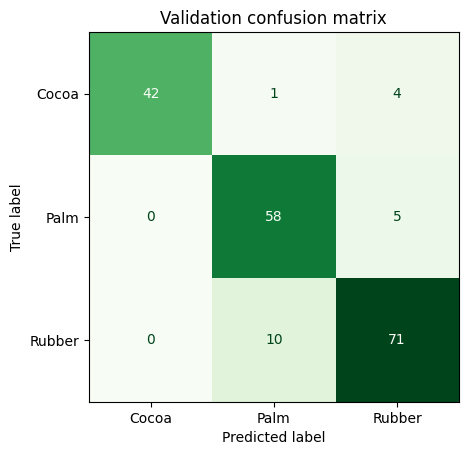

In [70]:
ConfusionMatrixDisplay.from_predictions(
    y_valid, valid_predictions, labels=crop_names, cmap='Greens', colorbar=False)
plt.title('Validation confusion matrix')
plt.show()

### 10.2 Feature importance

The 15 highest feature importances are shown. These scores describe the fitted model and do not establish causal relationships.

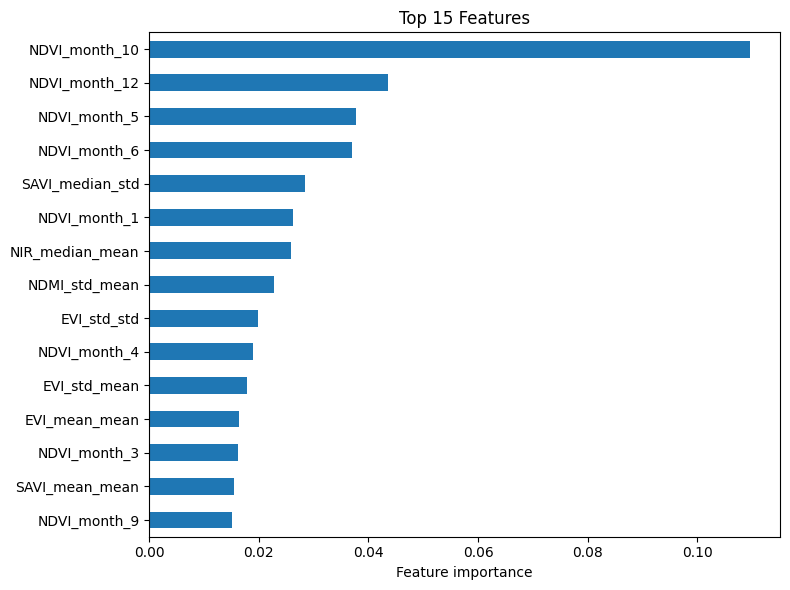

In [72]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.nlargest(15).sort_values().plot.barh(figsize=(8, 6))
plt.title('Top 15 Features')
plt.xlabel('Feature importance')
plt.tight_layout()
plt.show()

## 11. Final XGBoost Model training

A new imputer and Xgboost model are fitted on all labelled samples using the same settings. Test features are transformed with the training-fitted imputer.


In [74]:
final_imputer = SimpleImputer(strategy='median', keep_empty_features=True)
X_all_filled = final_imputer.fit_transform(X)
X_test_filled = final_imputer.transform(X_test)
y_numeric = label_encoder.fit_transform(y)
final_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_all_filled, y_numeric)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [76]:
test_predictions = final_model.predict(X_test_filled)
test_predictions = label_encoder.inverse_transform(test_predictions)

print('Number of predictions:', len(test_predictions))
print(test_predictions[:10])

Number of predictions: 282
['Palm' 'Palm' 'Rubber' 'Rubber' 'Rubber' 'Rubber' 'Rubber' 'Palm'
 'Rubber' 'Rubber']


## 12. Submission export

Predictions are joined to the submission template by sample ID. The output contains exactly `ID` and `Target`, with crop names as target values.

In [78]:
prediction_table = pd.DataFrame({
    'ID': X_test.index,
    'Target': test_predictions
})

submission = sample_submission[['ID']].merge(
    prediction_table, on='ID', how='left', validate='one_to_one', sort=False)

submission.head()

,ID,Target
0,ID_731818,Palm
1,ID_790093,Palm
2,ID_931033,Rubber
3,ID_079024,Rubber
4,ID_691532,Rubber


### 12.1 Submission validation

Checks enforce unique IDs, template ordering, complete predictions and valid crop labels before writing `submission.csv`.

In [79]:
assert submission.columns.tolist() == ['ID', 'Target']
assert submission['ID'].tolist() == sample_submission['ID'].tolist()
assert submission['ID'].is_unique
assert submission['Target'].notna().all()
assert submission['Target'].isin(crop_names).all()

submission.to_csv(RESULTS_PATH / 'submission.csv', index=False)
print('Saved:', RESULTS_PATH / 'submission.csv')

Saved: /content/drive/MyDrive/crop_classify/results/submission.csv


In [80]:
from google.colab import files

files.download(str(RESULTS_PATH / 'submission.csv'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>